# **Kfall Dataset Exploration**

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import seaborn as sns

## Kfall Description


* 32 young subjects
* 21 types of activities of daily living (ADLs) 
* 15 types of falls from an inertial sensor attached on low back
* In total, it contains 5075 motion files with 2729 ADL motions and 2346 fall motions
* The motion sensor is simply placed on the waist - 1 accelerometer and 1 gyroscope
* The dataset is available here : https://sites.google.com/view/kfalldataset

In [2]:
sensor_path = "Kfall/sensor_data_new"

subjects = os.listdir(sensor_path)
print("Subjects number:", len(subjects))
print(subjects)

Subjects number: 32
['SA06', 'SA07', 'SA08', 'SA09', 'SA10', 'SA11', 'SA12', 'SA13', 'SA14', 'SA15', 'SA16', 'SA17', 'SA18', 'SA19', 'SA20', 'SA21', 'SA22', 'SA23', 'SA24', 'SA25', 'SA26', 'SA27', 'SA28', 'SA29', 'SA30', 'SA31', 'SA32', 'SA33', 'SA35', 'SA36', 'SA37', 'SA38']


In [3]:
total_files = 0

for subject in subjects:
    files = os.listdir(os.path.join(sensor_path, subject))
    total_files += len(files)

print("Total number of recordings:", total_files)

Total number of recordings: 5075


In [4]:
recordings_per_subject = {}

for subject in subjects:
    subject_path = os.path.join(sensor_path, subject)
    files = [f for f in os.listdir(subject_path) if f.endswith(".csv")]
    recordings_per_subject[subject] = len(files)

df_recordings = pd.DataFrame.from_dict(recordings_per_subject, orient="index", columns=["n_recordings"])
df_recordings

,n_recordings
SA06,156
SA07,150
SA08,163
SA09,153
SA10,159
SA11,163
SA12,142
SA13,160
SA14,162
SA15,162


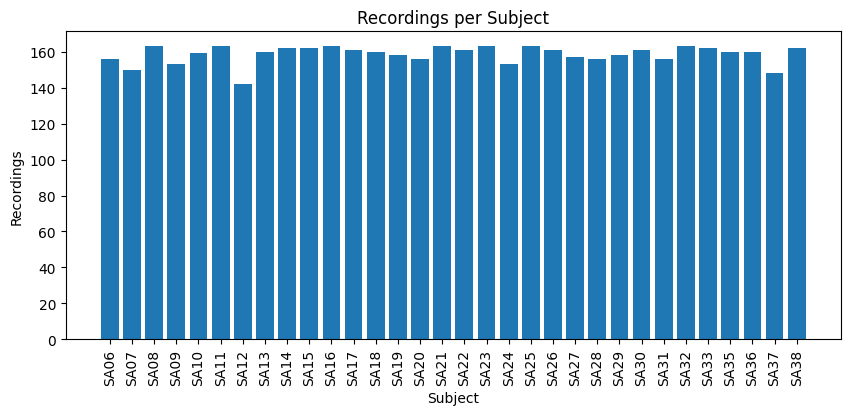

In [5]:
plt.figure(figsize=(10,4))
plt.bar(df_recordings.index, df_recordings["n_recordings"])
plt.xticks(rotation=90)
plt.title("Recordings per Subject")
plt.xlabel("Subject")
plt.ylabel("Recordings")
plt.show()

In [6]:
label_path = "Kfall/label_data_new"

labels_list = []

for file in os.listdir(label_path):
    if file.endswith(".xlsx"):
        df = pd.read_excel(os.path.join(label_path, file))

        df.columns = df.columns.astype(str).str.strip().str.lower()

        df["subject"] = file.replace(".xlsx", "")

        labels_list.append(df)

labels_df = pd.concat(labels_list, ignore_index=True)

print("\nPreview labels_df:")
labels_df.head()


Preview labels_df:


,task code (task id),description,trial id,fall_onset_frame,fall_impact_frame,subject
0,F01 (20),Forward fall when trying to sit down,1,130,208,SA06_label
1,NaN,NaN,2,184,272,SA06_label
2,NaN,NaN,3,184,260,SA06_label
3,NaN,NaN,4,151,231,SA06_label
4,NaN,NaN,5,128,223,SA06_label


In [ ]:
data_list = []

for subject in subjects:
    subject_path = os.path.join(sensor_path, subject)
    if not os.path.isdir(subject_path):
        continue
        
    files = [f for f in os.listdir(subject_path) if f.endswith(".csv")]
    
    for f in files:
        # Usar regex para extrair Subject, Task e Trial do nome: S01T01R01
        match = re.search(r'S(\d+)T(\d+)R(\d+)', f)
        if match:
            s_id = int(match.group(1))
            t_id = int(match.group(2))
            r_id = int(match.group(3))
            
            # Classificar ADL (1-19) ou Fall (20-34)
            category = "Fall" if 20 <= t_id <= 34 else "ADL"
            
            data_list.append({
                "subject": f"S{s_id:02d}",
                "task_id": t_id,
                "trial_id": r_id,
                "category": category,
                "filename": f
            })

df_meta = pd.DataFrame(data_list)

## ADL Vs Fall (General)

C:\Users\leono\AppData\Local\Temp\ipykernel_26280\4254865843.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_meta, x='category', palette='viridis')


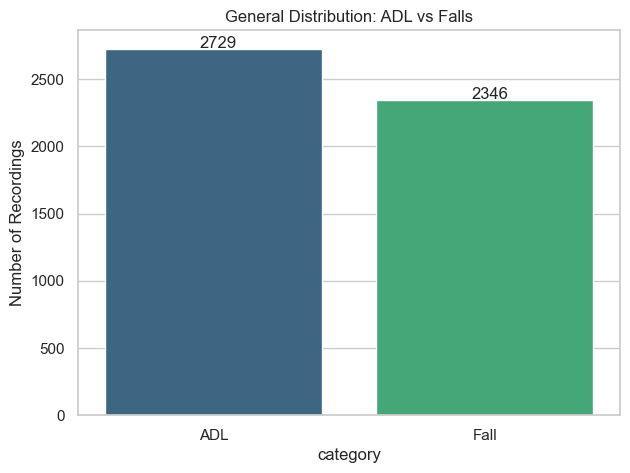

In [12]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df_meta, x='category', palette='viridis')
plt.title("General Distribution: ADL vs Falls")
plt.ylabel("Number of Recordings")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x()+0.35, p.get_height()+5))
plt.show()

## ADL Vs Fall (Per subject)

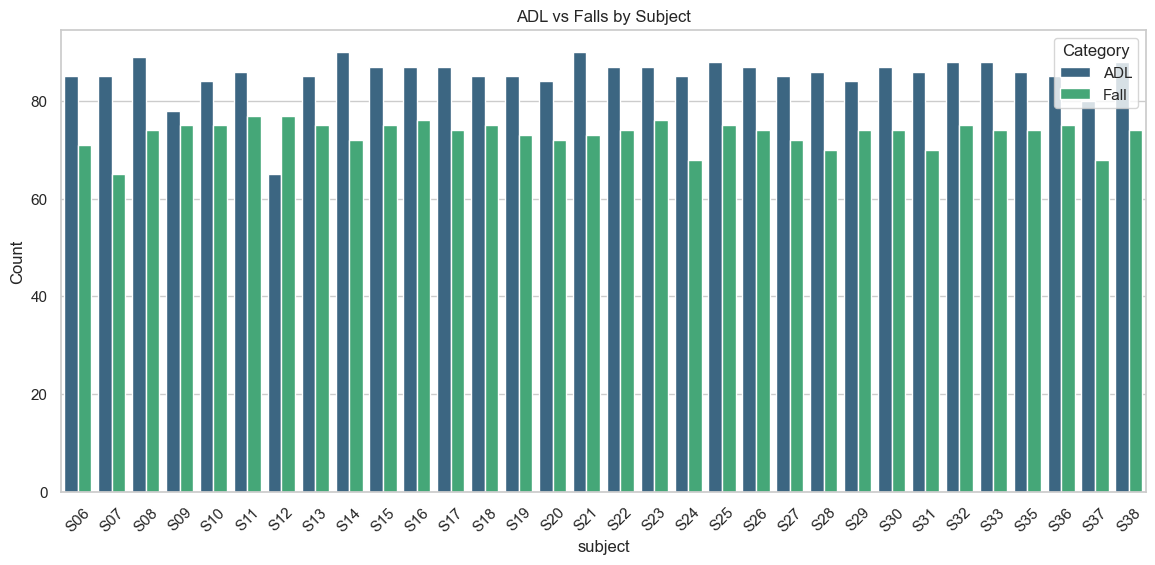

In [19]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df_meta, x='subject', hue='category', palette='viridis')
plt.title("ADL vs Falls by Subject")
plt.xticks(rotation=45)
plt.ylabel("Count")
plt.legend(title="Category")
plt.show()

## Fall Types (General)

C:\Users\leono\AppData\Local\Temp\ipykernel_26280\2372180216.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_falls, x='task_id', palette='magma')


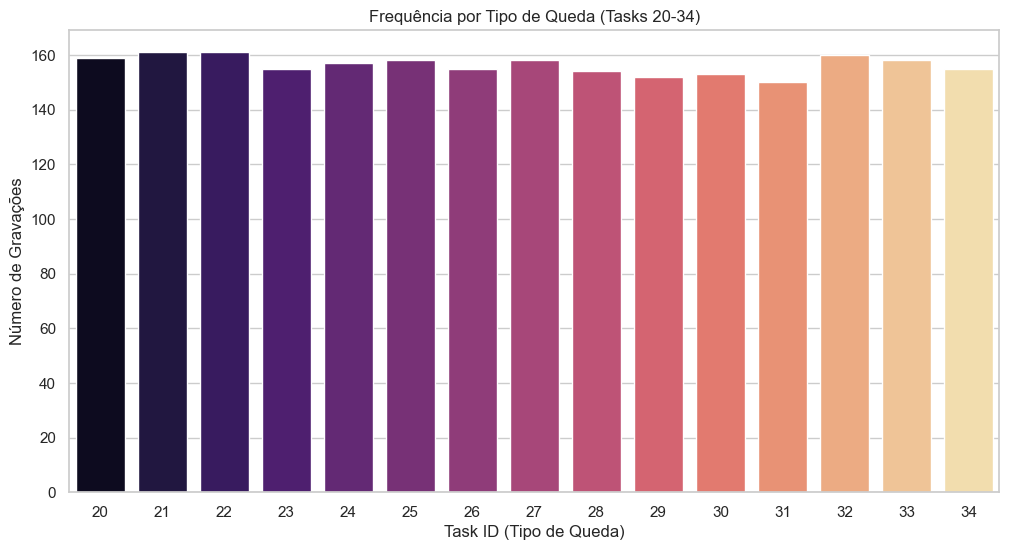

In [14]:
df_falls = df_meta[df_meta['category'] == "Fall"].copy()

plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_falls, x='task_id', palette='magma')
plt.title("Frequência por Tipo de Queda (Tasks 20-34)")
plt.xlabel("Task ID (Tipo de Queda)")
plt.ylabel("Número de Gravações")
plt.show()

## Fall Types (per subject)

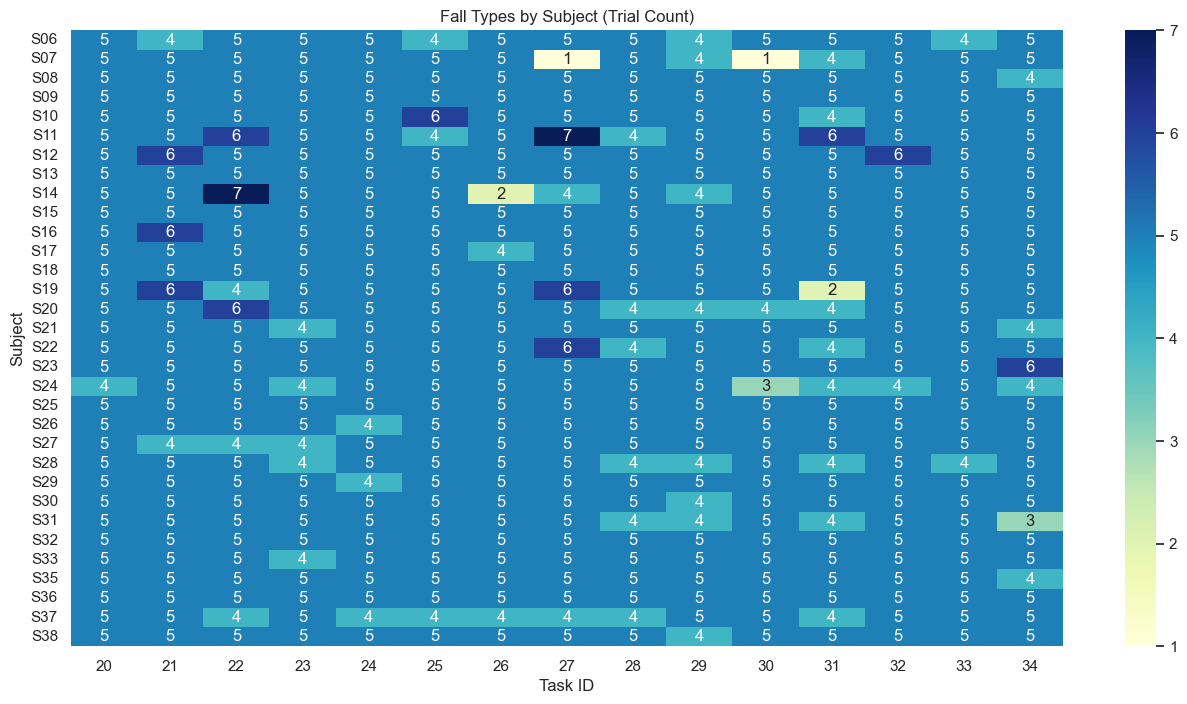

In [16]:
fall_pivot = df_falls.groupby(['subject', 'task_id']).size().unstack(fill_value=0)

plt.figure(figsize=(16, 8))
sns.heatmap(fall_pivot, annot=True, cmap="YlGnBu", fmt='d')
plt.title("Fall Types by Subject (Trial Count)")
plt.xlabel("Task ID")
plt.ylabel("Subject")
plt.show()

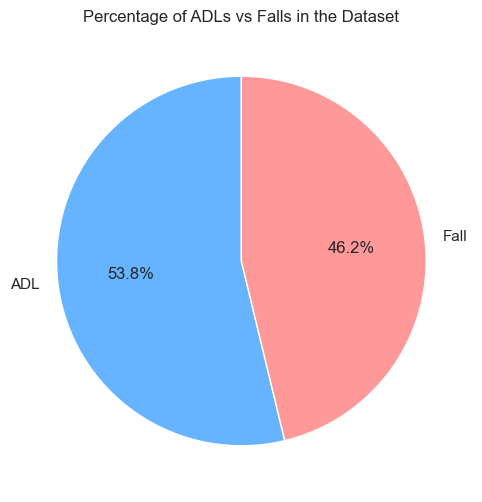

In [18]:
plt.figure(figsize=(6, 6))
df_meta['category'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title("Percentage of ADLs vs Falls in the Dataset")
plt.ylabel("") 
plt.show()

## Example Acc signal + Magnitude

In [22]:
example = "Kfall/sensor_data_new/SA06/S06T01R01.csv"

df = pd.read_csv(example)
print(df.head())
print(df.columns)

   TimeStamp(s)  FrameCounter   AccX   AccY   AccZ      GyrX      GyrY  \
0          0.01             1 -0.053 -1.004  0.000 -0.057296  0.401071   
1          0.02             2 -0.054 -1.007  0.000 -0.057296  0.229183   
2          0.03             3 -0.056 -1.009 -0.004 -0.458366  0.286479   
3          0.04             4 -0.053 -1.011 -0.009 -0.916733  0.458366   
4          0.05             5 -0.052 -1.012 -0.011 -1.088620  0.343775   

       GyrZ     EulerX    EulerY     EulerZ  
0  0.343775  87.788625 -2.859060 -20.202499  
1  0.229183  87.788625 -2.864790 -20.196769  
2  0.171887  87.782895 -2.864790 -20.196769  
3  0.229183  87.771436 -2.870520 -20.191040  
4  0.401071  87.817273 -2.841872 -20.191040  
Index(['TimeStamp(s)', 'FrameCounter', 'AccX', 'AccY', 'AccZ', 'GyrX', 'GyrY',
       'GyrZ', 'EulerX', 'EulerY', 'EulerZ'],
      dtype='str')


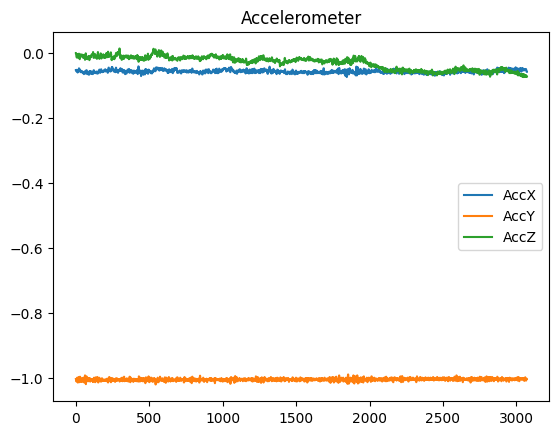

In [23]:
plt.plot(df["AccX"])
plt.plot(df["AccY"])
plt.plot(df["AccZ"])
plt.title("Accelerometer")
plt.legend(["AccX", "AccY", "AccZ"])
plt.show()

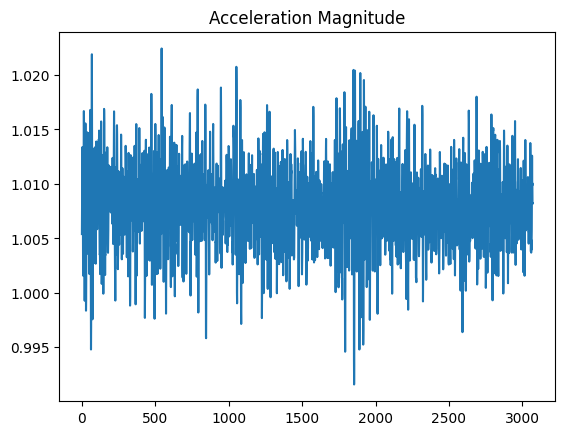

In [24]:
df["acc_mag"] = np.sqrt(df.AccX**2 + df.AccY**2 + df.AccZ**2)

plt.plot(df["acc_mag"])
plt.title("Acceleration Magnitude")
plt.show()

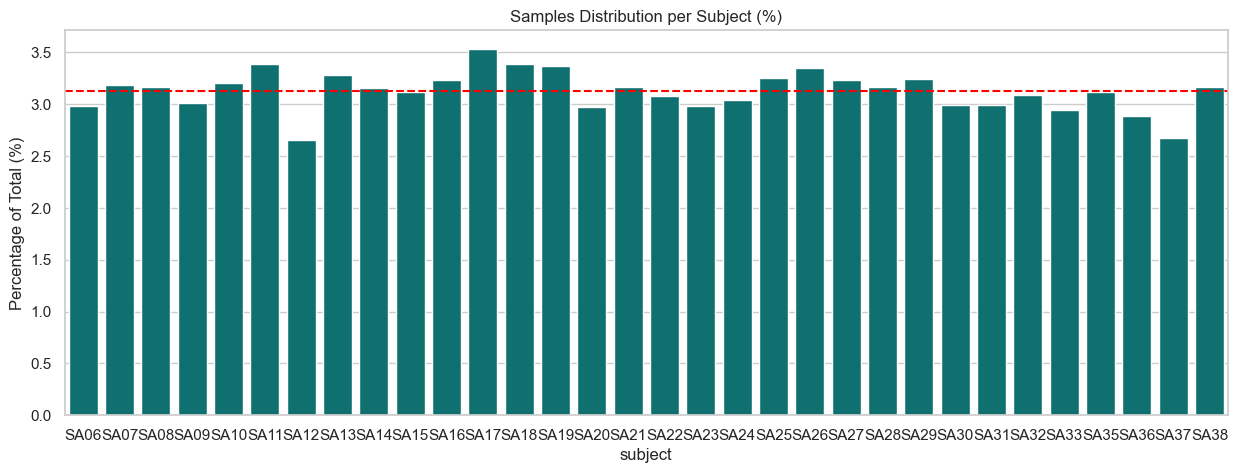

In [21]:
kfall_metadata = []

for subject in subjects:
    subject_path = os.path.join(sensor_path, subject)
    files = [f for f in os.listdir(subject_path) if f.endswith(".csv")]
    for f in files:
        row_count = sum(1 for line in open(os.path.join(subject_path, f))) - 1
        
        t_id = int(re.search(r'T(\d+)', f).group(1))
        category = "Fall" if 20 <= t_id <= 34 else "ADL"
        
        kfall_metadata.append({
            "subject": subject,
            "category": category,
            "length": row_count
        })

df_kfall_meta = pd.DataFrame(kfall_metadata)


kfall_subj = df_kfall_meta.groupby('subject')['length'].sum().reset_index()
kfall_subj['percentage'] = (kfall_subj['length'] / kfall_subj['length'].sum()) * 100

plt.figure(figsize=(15, 5))
sns.barplot(data=kfall_subj, x='subject', y='percentage', color='teal')
plt.axhline(100/len(kfall_subj), color='red', linestyle='--')
plt.title("Samples Distribution per Subject (%)")
plt.ylabel("Percentage of Total (%)")
plt.show()

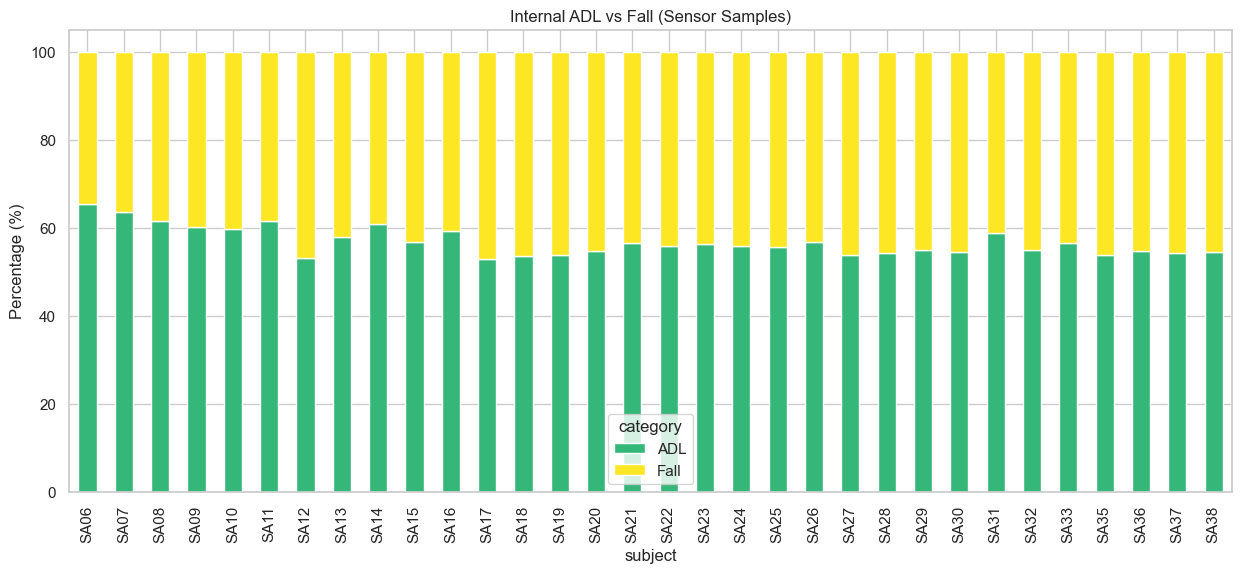

In [22]:
kfall_prop = df_kfall_meta.groupby(['subject', 'category'])['length'].sum().unstack(fill_value=0)
kfall_prop_norm = kfall_prop.div(kfall_prop.sum(axis=1), axis=0) * 100

kfall_prop_norm.plot(kind='bar', stacked=True, figsize=(15, 6), color=['#35b779', '#fde725'])
plt.title("Internal ADL vs Fall (Sensor Samples)")
plt.ylabel("Percentage (%)")
plt.show()

In [23]:
top5_kfall = kfall_subj.sort_values(by='length', ascending=False).head(5)
bottom5_kfall = kfall_subj.sort_values(by='length', ascending=True).head(5)

print("-" * 30)
print("Top 5 subject (more samples)")
print(top5_kfall[['subject', 'length', 'percentage']].to_string(index=False))



------------------------------
Top 5 subject (more samples)
subject  length  percentage
   SA17  141304    3.536933
   SA11  135361    3.388176
   SA18  135343    3.387725
   SA19  134392    3.363921
   SA26  133607    3.344272
